In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("joniarroba/noshowappointments")

import os
print(os.listdir(path))

['KaggleV2-May-2016.csv']


In [2]:
csv_file = os.path.join(path, 'KaggleV2-May-2016.csv')
df = pd.read_csv(csv_file)

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
list(df.columns)

['PatientId',
 'AppointmentID',
 'Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Neighbourhood',
 'Scholarship',
 'Hipertension',
 'Diabetes',
 'Alcoholism',
 'Handcap',
 'SMS_received',
 'No-show']

In [5]:
#Rename columns with wrong syntaxes
df = df.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap'})

In [6]:
#Check duplicate values
df.duplicated().sum()

np.int64(0)

In [7]:
#Missing values
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hypertension      0
Diabetes          0
Alcoholism        0
Handicap          0
SMS_received      0
No-show           0
dtype: int64

In [8]:
df.shape

(110527, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hypertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handicap        110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [10]:
#Convert dates
df['Scheduled Day'] = pd.to_datetime(df['ScheduledDay'])

df["Appointment Day"]= pd.to_datetime(df['AppointmentDay'])

df['Time']= pd.to_datetime(df['ScheduledDay']).dt.time

In [11]:
#Extract days of the week, months and week-ends
#Days of the week
df['Appointment weekday'] = df['Appointment Day'].dt.day_name()

#Month
df['Appointment month'] = df['Appointment Day'].dt.month_name()

#Week-ends
df['Appointment on Weekend'] = df['Appointment Day'].dt.weekday >= 5

In [12]:
#Time elapsed between scheduled day and appointment day
df["Waiting Days"]= (df['Appointment Day'].dt.normalize() - df['Scheduled Day'].dt.normalize())
df['Waiting Days'] = df['Waiting Days'].dt.days

In [13]:
#Check negative values
df[df['Waiting Days']<0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,...,Handicap,SMS_received,No-show,Scheduled Day,Appointment Day,Time,Appointment weekday,Appointment month,Appointment on Weekend,Waiting Days
27033,7.839273e+12,5679978,M,2016-05-10T10:51:53Z,2016-05-09T00:00:00Z,38,RESISTÊNCIA,0,0,0,...,1,0,Yes,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,10:51:53,Monday,May,False,-1
55226,7.896294e+12,5715660,F,2016-05-18T14:50:41Z,2016-05-17T00:00:00Z,19,SANTO ANTÔNIO,0,0,0,...,1,0,Yes,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,14:50:41,Tuesday,May,False,-1
64175,2.425226e+13,5664962,F,2016-05-05T13:43:58Z,2016-05-04T00:00:00Z,22,CONSOLAÇÃO,0,0,0,...,0,0,Yes,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,13:43:58,Wednesday,May,False,-1
71533,9.982316e+14,5686628,F,2016-05-11T13:49:20Z,2016-05-05T00:00:00Z,81,SANTO ANTÔNIO,0,0,0,...,0,0,Yes,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,13:49:20,Thursday,May,False,-6
72362,3.787482e+12,5655637,M,2016-05-04T06:50:57Z,2016-05-03T00:00:00Z,7,TABUAZEIRO,0,0,0,...,0,0,Yes,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,06:50:57,Tuesday,May,False,-1


In [14]:
#Drop negative values
df = df[df['Waiting Days'] >= 0]

In [15]:
df['Waiting Days'].describe()

count    110522.000000
mean         10.184253
std          15.255115
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Waiting Days, dtype: float64

In [16]:
#Check extreme waiting days
df[df['Waiting Days'] > 100][['PatientId', 'Scheduled Day', 'Appointment Day', 'Waiting Days']]

,PatientId,Scheduled Day,Appointment Day,Waiting Days
953,4.616858e+12,2016-01-05 15:02:46+00:00,2016-04-29 00:00:00+00:00,115
954,1.423329e+12,2016-01-05 11:53:44+00:00,2016-04-29 00:00:00+00:00,115
955,1.596183e+14,2016-01-11 10:20:41+00:00,2016-04-29 00:00:00+00:00,109
956,3.136481e+14,2016-01-11 09:57:10+00:00,2016-04-29 00:00:00+00:00,109
957,9.189694e+13,2016-01-11 09:08:10+00:00,2016-04-29 00:00:00+00:00,109
...,...,...,...,...
102872,2.552524e+14,2015-12-15 10:15:50+00:00,2016-06-08 00:00:00+00:00,176
110296,7.682333e+13,2016-02-05 10:37:16+00:00,2016-06-06 00:00:00+00:00,122
110321,1.388630e+11,2016-02-11 16:14:32+00:00,2016-06-01 00:00:00+00:00,111
110335,3.747953e+11,2016-02-11 16:39:26+00:00,2016-06-01 00:00:00+00:00,111


In [17]:
#Check gender values
df['Gender'].value_counts()

Gender
F    71837
M    38685
Name: count, dtype: int64

In [18]:
#Check no show values
df['No-show'].value_counts()

No-show
No     88208
Yes    22314
Name: count, dtype: int64

In [19]:
#Check ages
df['Age'].value_counts()

Age
 0      3539
 1      2273
 52     1746
 49     1652
 53     1651
        ... 
 115       5
 100       4
 102       2
 99        1
-1         1
Name: count, Length: 104, dtype: int64

In [20]:
#Drop negative ages
df = df[df['Age']>=0]

In [21]:
#Analysis

*“What is the overall no-show rate?”*

In [22]:
#Overall no-show rate
df['No-show'].value_counts(normalize=True)['Yes'] * 100

np.float64(20.18982817745044)

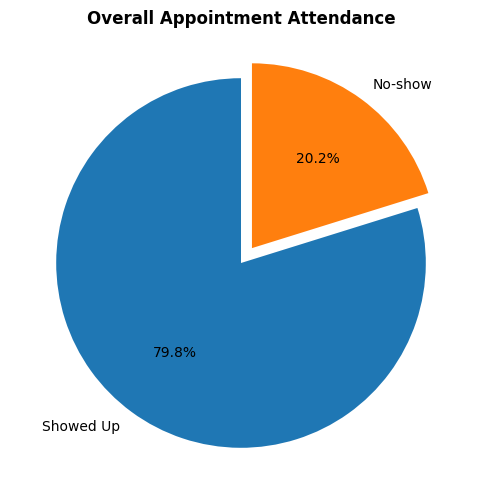

In [23]:
#Pie chart
no_show_counts = df['No-show'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    no_show_counts,
    labels=['Showed Up', 'No-show'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)
)

plt.title('Overall Appointment Attendance', fontweight='bold')
plt.show()

**The analysis shows that only a small proportion of patients do not show up for their appointments, which represents one scheduled appointment out of five.**

*“Does age influence attendance?”*

In [24]:
df['Age'].describe()

count    110521.000000
mean         37.089386
std          23.109885
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [25]:
#Create age groups
df['Age_group'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 70, 120], labels=['0-18', '19-30', "31-50", '51-70', '70+'])


In [26]:
#Age influence
df['No_show_values'] = df['No-show'].map({'No':0, 'Yes': 1})

age_influence = df.groupby('Age_group')['No_show_values'].mean()*100
age_influence

/tmp/ipykernel_16/3675046.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_influence = df.groupby('Age_group')['No_show_values'].mean()*100


Age_group
0-18     22.534155
19-30    24.703215
31-50    20.701707
51-70    16.271881
70+      15.830611
Name: No_show_values, dtype: float64

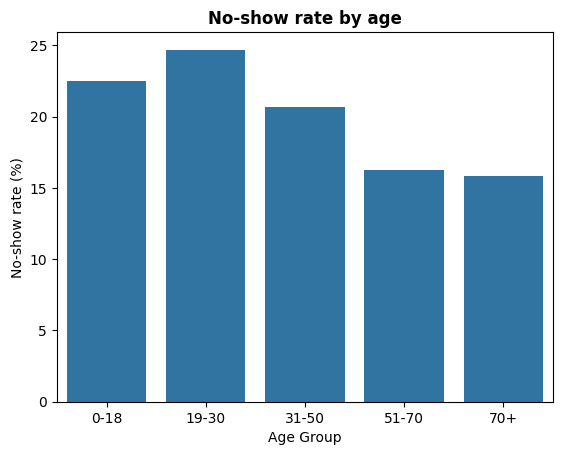

In [27]:
#Bar chart
sns.barplot(x=age_influence.index, y=age_influence.values)
plt.xlabel('Age Group')
plt.ylabel('No-show rate (%)')
plt.title('No-show rate by age', fontweight='bold')
plt.show()

**The results indicate that no-show rates are higher among younger patients and decrease progressively with age. Patients under 30 years old are the most likely to miss their appointments, while attendance rates improve steadily among older age groups. 
Although the dataset does not provide information about the reasons behind this behavior, one possible explanation is that older individuals may be more aware of the importance of medical follow-up due to age-related health concerns. Younger patients, who are often in better overall health, may be less likely to prioritize medical appointments.**

*“Does gender influence attendance?”*

In [28]:
df['Gender_label'] = df['Gender'].map({'M': 'Male', 'F': 'Female'})
gender_influence = df.groupby('Gender_label')['No_show_values'].mean()*100
gender_influence

Gender_label
Female    20.311543
Male      19.963810
Name: No_show_values, dtype: float64

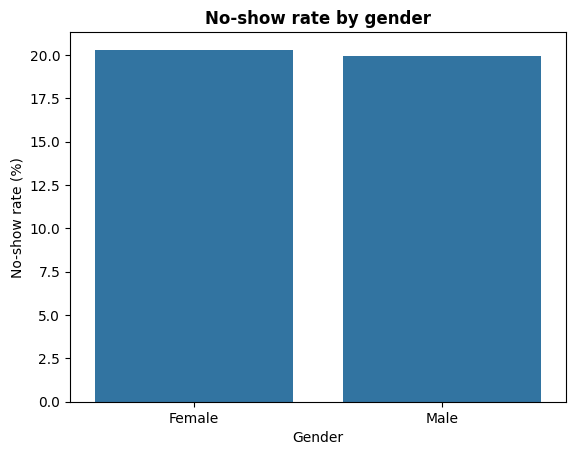

In [29]:
#Bar chart
sns.barplot(x=gender_influence.index, y=gender_influence.values)
plt.xlabel('Gender')
plt.ylabel('No-show rate (%)')
plt.title('No-show rate by gender', fontweight='bold')
plt.show()

**Female patients have a no-show rate of 20.31%, compared with 19.96% for male patients. The difference is very small, suggesting that gender has little influence on appointment attendance.**

*“Do SMS reminders reduce no-shows?”*

In [30]:
sms_influence = df.groupby('SMS_received')['No_show_values'].mean()*100
sms_influence

SMS_received
0    16.697984
1    27.574545
Name: No_show_values, dtype: float64

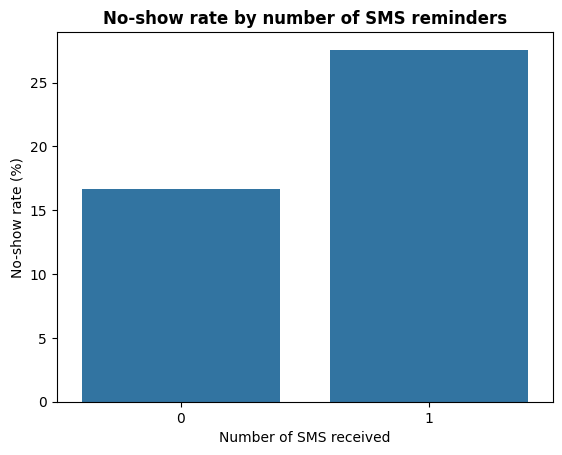

In [31]:
#Bar chart
sns.barplot(x=sms_influence.index, y=sms_influence.values)
sms_influence.index = sms_influence.index.map({0: "No SMS",1: "SMS received"})
plt.xlabel('Number of SMS received')
plt.ylabel('No-show rate (%)')
plt.title('No-show rate by number of SMS reminders', fontweight='bold')
plt.show()

**The analysis shows that patients who received an SMS reminder have a higher no-show rate than those who did not receive one. However, this result should be interpreted with caution, as the dataset does not provide information about how SMS reminders were assigned.
Several factors could explain this finding. For example, patients may have been given the option to receive SMS reminders when scheduling their appointments, resulting in differences between the two groups. It is also possible that healthcare providers prioritized reminders for patients considered more likely to miss their appointments, such as those with complex medical conditions or a history of missed visits. Since this information is not available in the dataset, no causal relationship can be established between SMS reminders and appointment attendance.**

*“Which neighbourhoods have the highest no-show rates?”*

In [32]:
neighbourhood_rate = df.groupby('Neighbourhood')['No_show_values'].mean()*100
neighbourhood_rate

Neighbourhood
AEROPORTO              12.500000
ANDORINHAS             23.032714
ANTÔNIO HONÓRIO        18.450185
ARIOVALDO FAVALESSA    21.985816
BARRO VERMELHO         21.513002
                         ...    
SÃO JOSÉ               21.648963
SÃO PEDRO              21.037582
TABUAZEIRO             18.268924
UNIVERSITÁRIO          21.052632
VILA RUBIM             16.568743
Name: No_show_values, Length: 81, dtype: float64

In [33]:
#Sort neighbourhoods by descending order
neighbourhood_sorted = neighbourhood_rate.sort_values(ascending=False)
neighbourhood_sorted

Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.000000
SANTOS DUMONT                   28.918495
SANTA CECÍLIA                   27.455357
SANTA CLARA                     26.482213
ITARARÉ                         26.266363
                                  ...    
SOLON BORGES                    14.712154
MÁRIO CYPRESTE                  14.555256
AEROPORTO                       12.500000
ILHA DO BOI                      8.571429
PARQUE INDUSTRIAL                0.000000
Name: No_show_values, Length: 81, dtype: float64

We checked the number of appointments in each neighbourhood to investigate the 100% no-show rate in ILHAS OCEÂNICAS DE TRINDADE. This helped us determine whether the result was due to a limited number of observations rather than a genuine pattern.

In [34]:
df['Neighbourhood'].value_counts()

Neighbourhood
JARDIM CAMBURI                 7717
MARIA ORTIZ                    5805
RESISTÊNCIA                    4430
JARDIM DA PENHA                3877
ITARARÉ                        3514
                               ... 
ILHA DO BOI                      35
ILHA DO FRADE                    10
AEROPORTO                         8
ILHAS OCEÂNICAS DE TRINDADE       2
PARQUE INDUSTRIAL                 1
Name: count, Length: 81, dtype: int64

The neighbourhood ILHAS OCEÂNICAS DE TRINDADE shows a 100% no-show rate. However, this neighbourhood contains only two appointments, making the result unreliable. We therefore excluded it from the analysis.

In [35]:
#Drop ILHAS OCEÂNICAS DE TRINDADE
neighbourhood_rate = neighbourhood_rate[df['Neighbourhood'].value_counts() > 30]

In [36]:
#Top 10 neighbourhoods with the highest no show rate
top_10 = neighbourhood_rate.sort_values(ascending=False).head(10)
top_10

Neighbourhood
SANTOS DUMONT        28.918495
SANTA CECÍLIA        27.455357
SANTA CLARA          26.482213
ITARARÉ              26.266363
JESUS DE NAZARETH    24.395373
HORTO                24.000000
ILHA DO PRÍNCIPE     23.477493
CARATOÍRA            23.040936
ANDORINHAS           23.032714
PRAIA DO SUÁ         22.826087
Name: No_show_values, dtype: float64

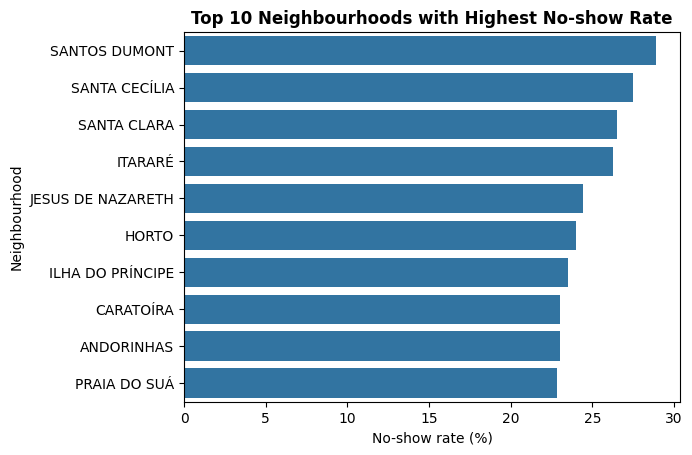

In [37]:
#Bar plot
sns.barplot(x=top_10.values, y=top_10.index)
plt.xlabel('No-show rate (%)')
plt.ylabel('Neighbourhood')
plt.title("Top 10 Neighbourhoods with Highest No-show Rate", fontweight='bold')
plt.show()

**The analysis reveals noticeable differences in no-show rates across neighbourhoods. Santos Dumont, Santa Cecília, Santa Clara and Itararé exhibit the highest absenteeism rates, all exceeding 26%.
These results suggest that geographical location may play a role in appointment attendance. However, the dataset does not provide information on socioeconomic factors, transportation access, or proximity to healthcare facilities. Therefore, while neighbourhood appears to be associated with no-show behavior, the underlying reasons for these differences cannot be determined from the available data.**

*“Does waiting time between scheduling and appointment affect attendance?”*

In [38]:
#Group waiting days by buckets
df['waiting_group'] = pd.cut(df['Waiting Days'], bins=[0, 7, 14, 30, 60, 180], labels=['0-7', '8-14', '15-30', '31-60','60+'])

In [39]:
waitingtime_influence = df.groupby('waiting_group')['No_show_values'].mean()*100
waitingtime_influence

/tmp/ipykernel_16/1630507887.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  waitingtime_influence = df.groupby('waiting_group')['No_show_values'].mean()*100


waiting_group
0-7      24.147895
8-14     30.469854
15-30    32.588797
31-60    34.154292
60+      28.448687
Name: No_show_values, dtype: float64

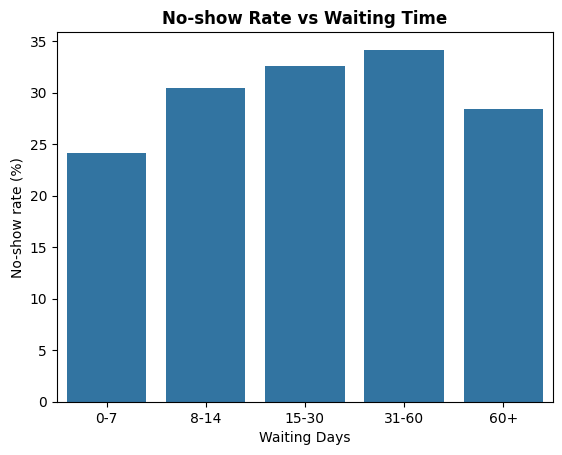

In [40]:
#Barplot
sns.barplot(x=waitingtime_influence.index, y=waitingtime_influence.values)
plt.xlabel("Waiting Days")
plt.ylabel('No-show rate (%)')
plt.title('No-show Rate vs Waiting Time', fontweight= 'bold')
plt.show()

**The analysis shows that no-show rates generally increase as the waiting time between booking and appointment increases. Patients with longer delays tend to miss their appointments more frequently than those with shorter waiting times. 
One possible explanation is that patients may no longer perceive the appointment as necessary, may have rescheduled their care elsewhere, or may simply forget about their appointment as the waiting time increases. However, these remain hypotheses, as the dataset does not provide information on patient intentions or external scheduling behavior. 
However, this trend is not strictly linear. A slight decrease is observed for the longest waiting period (60+ days), which may suggest that patients who wait very long for an appointment are either more committed to attending or represent a specific subgroup of patients with different healthcare needs.
Overall, waiting time appears to be an important factor associated with appointment attendance, although the relationship is not perfectly monotonic.**

*“Do days of the week affect attendance?”*

In [41]:
day_influence = df.groupby('Appointment weekday')['No_show_values'].mean()*100
day_influence

Appointment weekday
Friday       21.226142
Monday       20.644565
Saturday     23.076923
Thursday     19.349414
Tuesday      20.087370
Wednesday    19.686074
Name: No_show_values, dtype: float64

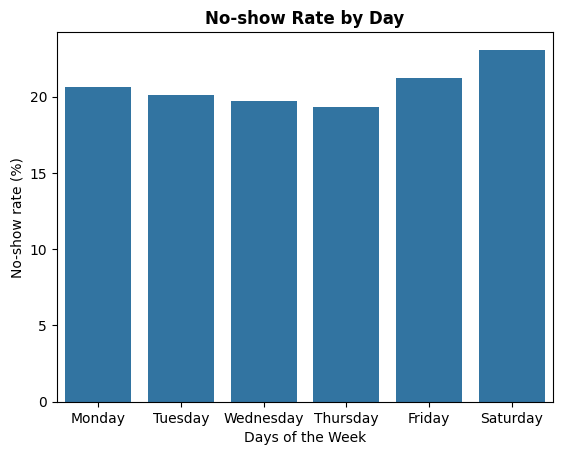

In [42]:
#Barplot
day_order = 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'
sns.barplot(x=day_influence.index, y=day_influence.values, order= day_order )
plt.xlabel("Days of the Week")
plt.ylabel('No-show rate (%)')
plt.title('No-show Rate by Day', fontweight= 'bold')
plt.show()

**The analysis shows relatively small variations in no-show rates across weekdays. Mid-week days such as Wednesday and Thursday tend to have slightly lower absenteeism rates, while Friday and especially Saturday show higher no-show rates.
However, the differences between weekdays are not very large, suggesting that the day of the week may have only a limited influence on appointment attendance compared to other factors such as waiting time or patient characteristics.**

*“Do months affect attendance?”*

In [43]:
#No show by month
month_influence = df.groupby('Appointment month')['No_show_values'].mean()*100
month_influence

Appointment month
April    19.567233
June     18.457467
May      20.781582
Name: No_show_values, dtype: float64

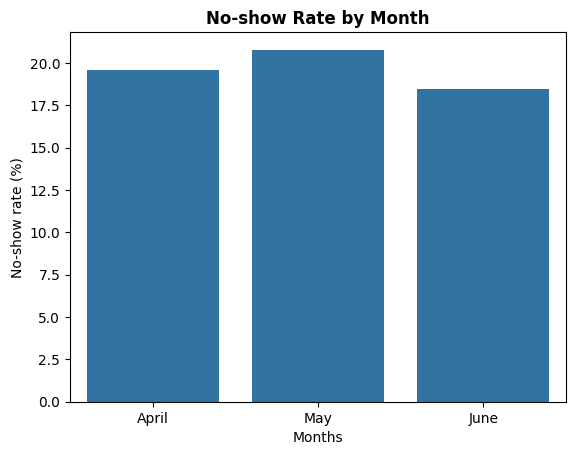

In [44]:
#Barplot
month_order = 'April', 'May', 'June'
sns.barplot(x=month_influence.index, y=month_influence.values, order= month_order )
plt.xlabel("Months")
plt.ylabel('No-show rate (%)')
plt.title('No-show Rate by Month', fontweight= 'bold')
plt.show()

**The absenteeism rate remains relatively stable across April, May, and June, with only minor variations (20% in May versus 18% in June).
These differences are not large enough to suggest a strong seasonal effect on appointment attendance within the observed period.**